# SignalCheck — Results Visualization

Generates the figures used in the paper draft, directly from the project's saved result files:
- `ablation_summary.csv` — per-modality ablation (Table II / Fig. 1)
- `ood_threshold_sweep_results.csv` — out-of-distribution evaluation progression, confusion matrices, and the threshold sweep (Table III / Fig. 2-4)

No numbers are hard-coded here beyond what is already recorded in those two CSV files, so re-running this notebook after a new evaluation run will regenerate the figures from the latest results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "figure.dpi": 130,
})

OUT_DIR = "paper_figures"
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Load results

In [2]:
ablation = pd.read_csv("ablation_summary.csv")
ablation["accuracy_pct"] = ablation["accuracy_mean"] * 100
ablation = ablation.set_index("config").loc[
    ["ocr_only", "caption_only", "text_only", "text_plus_cisf", "clip_only",
     "clip_plus_cisf", "text_plus_clip", "full_text_cisf_clip", "caption_plus_cisf_clip"]
].reset_index()
ablation[["config", "accuracy_pct"]]

,config,accuracy_pct
0,ocr_only,56.800
1,caption_only,74.400
2,text_only,76.550
3,text_plus_cisf,77.475
4,clip_only,95.575
5,clip_plus_cisf,95.575
6,text_plus_clip,95.425
7,full_text_cisf_clip,95.650
8,caption_plus_cisf_clip,95.400


In [3]:
ood = pd.read_csv("ood_threshold_sweep_results.csv")
ood

,stage,threshold,accuracy,fake_recall,real_precision,real_recall,fake_precision,tn_real_correct,fp_real_as_fake,fn_fake_as_real,tp_fake_correct
0,original_model,0.50,86.0,73.0,78.57,99.0,98.65,99,1,27,73
1,original_model,0.45,86.0,75.0,79.51,97.0,96.15,97,3,25,75
2,original_model,0.40,86.0,76.0,80.00,96.0,95.00,96,4,24,76
3,original_model,0.35,86.5,79.0,81.74,94.0,92.94,94,6,21,79
4,original_model,0.30,90.0,86.0,87.04,94.0,93.48,94,6,14,86
5,original_model,0.25,89.5,86.0,86.92,93.0,92.47,93,7,14,86
6,diverse_trained_model,0.30,91.5,91.0,91.09,92.0,91.92,92,8,9,91


## 2. Figure 1 — Per-modality ablation

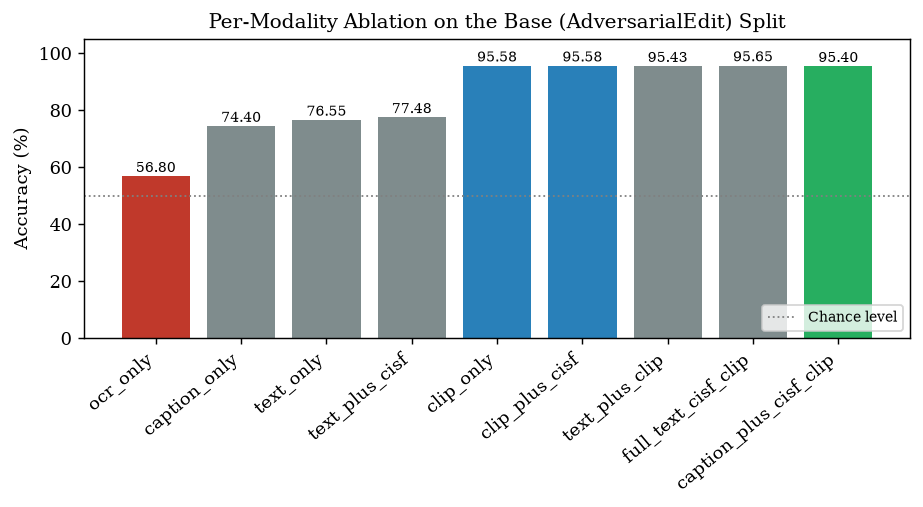

In [4]:
colors = [
    "#c0392b" if c == "ocr_only" else
    "#2980b9" if c in ("clip_only", "clip_plus_cisf") else
    "#27ae60" if c == "caption_plus_cisf_clip" else
    "#7f8c8d" for c in ablation["config"]
]

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.bar(range(len(ablation)), ablation["accuracy_pct"], color=colors)
ax.set_xticks(range(len(ablation)))
ax.set_xticklabels(ablation["config"], rotation=40, ha="right")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105)
ax.axhline(50, color="gray", linestyle=":", linewidth=1, label="Chance level")
for i, v in enumerate(ablation["accuracy_pct"]):
    ax.text(i, v + 1.5, f"{v:.2f}", ha="center", fontsize=8)
ax.set_title("Per-Modality Ablation on the Base (AdversarialEdit) Split")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig1_ablation.png"))
plt.show()

## 3. Figure 2 — OOD evaluation progression

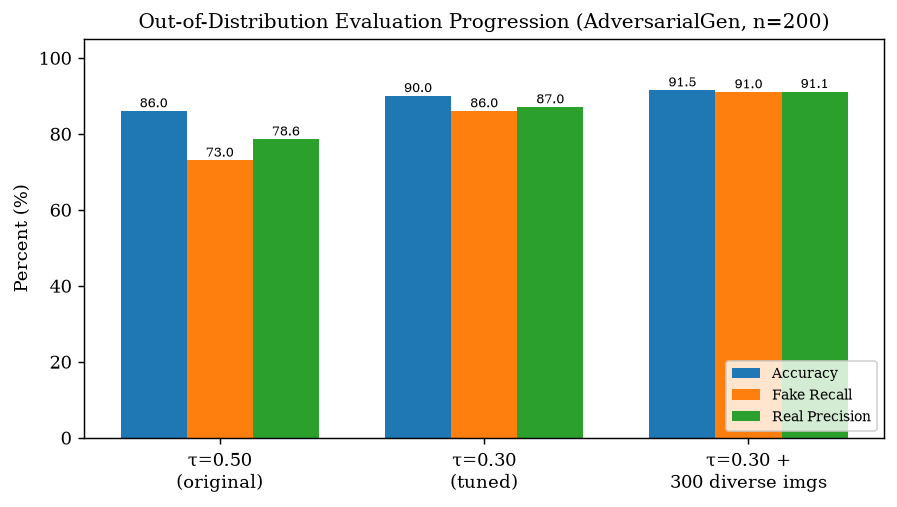

In [5]:
progression = ood[(ood["stage"] == "original_model") & (ood["threshold"].isin([0.50, 0.30]))].copy()
progression = pd.concat([progression, ood[ood["stage"] == "diverse_trained_model"]], ignore_index=True)

stage_labels = ["\u03c4=0.50\n(original)", "\u03c4=0.30\n(tuned)", "\u03c4=0.30 +\n300 diverse imgs"]
metrics = ["accuracy", "fake_recall", "real_precision"]
metric_labels = ["Accuracy", "Fake Recall", "Real Precision"]

x = np.arange(len(stage_labels))
width = 0.25
fig, ax = plt.subplots(figsize=(7.0, 4.0))
for i, (m, label) in enumerate(zip(metrics, metric_labels)):
    vals = progression[m].values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=label)
    for xi, v in zip(x + (i - 1) * width, vals):
        ax.text(xi, v + 1, f"{v:.1f}", ha="center", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(stage_labels)
ax.set_ylabel("Percent (%)")
ax.set_ylim(0, 105)
ax.set_title("Out-of-Distribution Evaluation Progression (AdversarialGen, n=200)")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig2_ood_progression.png"))
plt.show()

## 4. Figure 3 — Confusion matrices, before vs. after

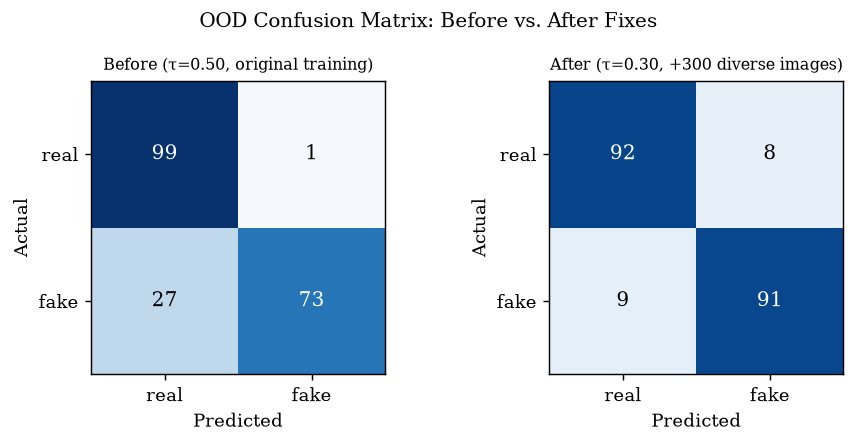

In [6]:
def confusion_from_row(row):
    return np.array([
        [row["tn_real_correct"], row["fp_real_as_fake"]],
        [row["fn_fake_as_real"], row["tp_fake_correct"]],
    ])

before = ood[(ood["stage"] == "original_model") & (ood["threshold"] == 0.50)].iloc[0]
after = ood[ood["stage"] == "diverse_trained_model"].iloc[0]
labels = ["real", "fake"]

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.4))
for ax, row, title in zip(
    axes,
    [before, after],
    ["Before (\u03c4=0.50, original training)", "After (\u03c4=0.30, +300 diverse images)"],
):
    cm = confusion_from_row(row)
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=100)
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title, fontsize=9)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > 55 else "black", fontsize=11)
fig.suptitle("OOD Confusion Matrix: Before vs. After Fixes", fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig3_confusion_matrices.png"))
plt.show()

## 5. Figure 4 — Decision-threshold sweep

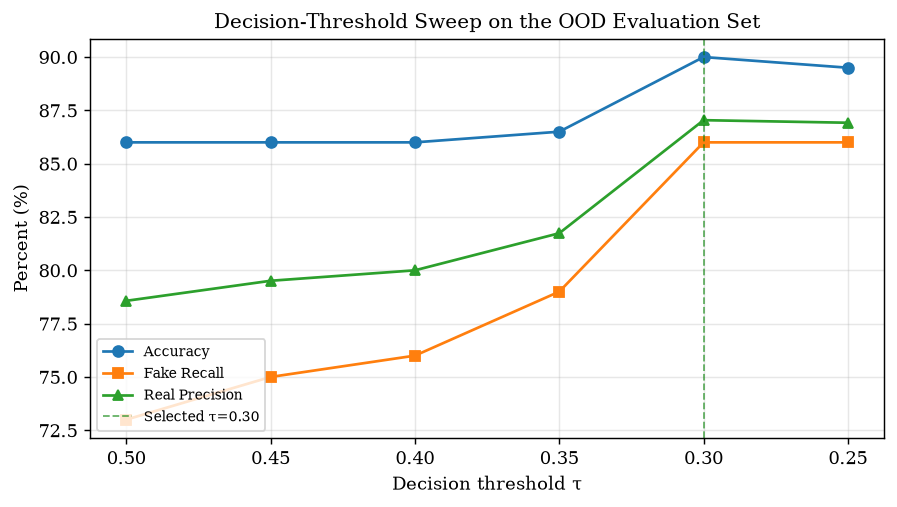

In [7]:
sweep = ood[ood["stage"] == "original_model"].sort_values("threshold", ascending=False)

fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.plot(sweep["threshold"], sweep["accuracy"], marker="o", label="Accuracy")
ax.plot(sweep["threshold"], sweep["fake_recall"], marker="s", label="Fake Recall")
ax.plot(sweep["threshold"], sweep["real_precision"], marker="^", label="Real Precision")
ax.axvline(0.30, color="green", linestyle="--", linewidth=1, alpha=0.6, label="Selected \u03c4=0.30")
ax.set_xlabel("Decision threshold \u03c4")
ax.set_ylabel("Percent (%)")
ax.invert_xaxis()
ax.set_title("Decision-Threshold Sweep on the OOD Evaluation Set")
ax.legend(loc="lower left", fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig4_threshold_sweep.png"))
plt.show()

## 6. Bonus — Baseline comparison (internal)

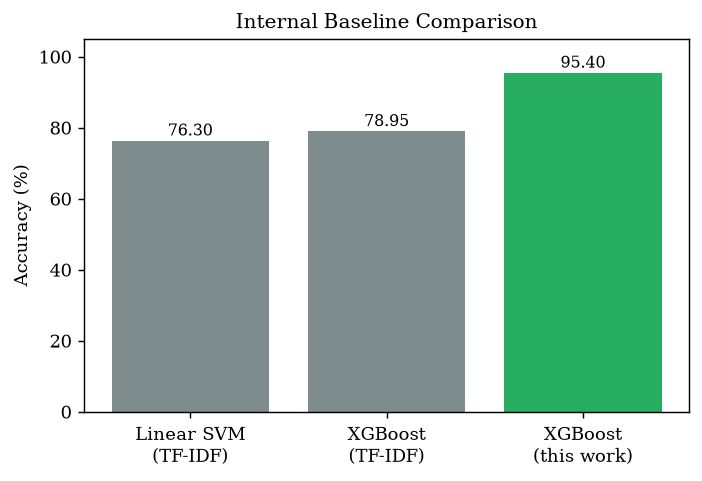

In [8]:
baselines = pd.DataFrame({
    "model": ["Linear SVM\n(TF-IDF)", "XGBoost\n(TF-IDF)", "XGBoost\n(this work)"],
    "accuracy": [76.30, 78.95, 95.40],
})
fig, ax = plt.subplots(figsize=(5.5, 3.8))
colors = ["#7f8c8d", "#7f8c8d", "#27ae60"]
ax.bar(baselines["model"], baselines["accuracy"], color=colors)
for i, v in enumerate(baselines["accuracy"]):
    ax.text(i, v + 1.5, f"{v:.2f}", ha="center", fontsize=9)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105)
ax.set_title("Internal Baseline Comparison")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig5_baselines.png"))
plt.show()